<a href="https://colab.research.google.com/github/Sebastian-Tamez/PDI_Laboratorio/blob/main/Practica6/P6_LabPDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PARTE I**

### **Ejercicio 1**

Para el primer ejercicio de esta actividad se realiza una suma ponderada, permitiendo controlar la contribución de cada imagen y ajustar el brillo del resultado. Se cargan dos imágenes médicas desde archivos y se convierten a escala de grises. Una de las imagenes se redimensiona para coincidir con el tamaño de la otra, garantizando la compatibilidad en la operación.

Posteriormente, se definen los parámetros de ponderación alpha y beta, los cuales determinan qué tanto influye cada imagen en el resultado final, así como un término adicional gamma que permite incrementar o disminuir el brillo global de la imagen resultante. La función *cv2.addWeighted* se encarga de realizar la operación correspondiente. Este proceso genera una nueva imagen que representa una fusión de ambas entradas.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

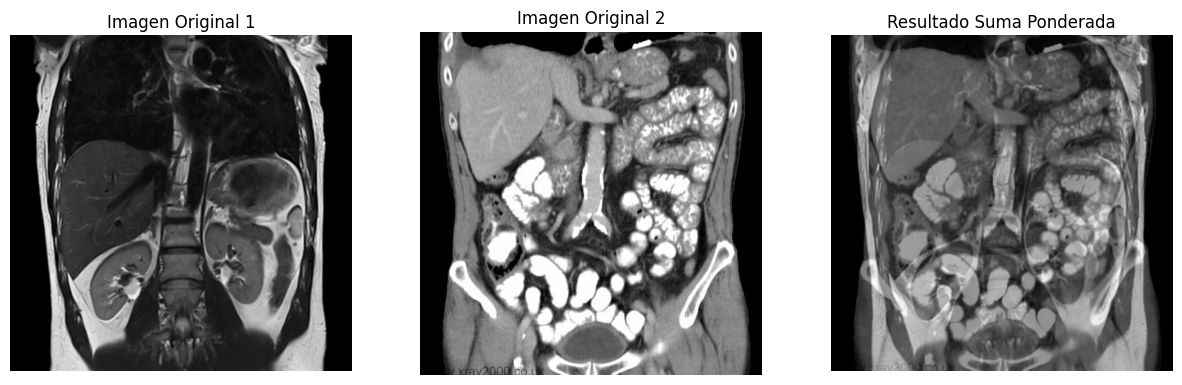

In [ ]:
# Cargar las dos imágenes
imagen2 = cv2.imread("MRI_ABDOMEN.jpg", cv2.IMREAD_GRAYSCALE)
imagen1 = cv2.imread("MRI_ABDOMEN2.jpg", cv2.IMREAD_GRAYSCALE)

# Redimensionar ambas imágenes al mismo tamaño
imagen2_res = cv2.resize(imagen2, (imagen1.shape[1], imagen1.shape[0]))

# Aplicar la suma ponderada
alpha = 0.5
beta = 0.5
gamma = 10

imagen_resultado = cv2.addWeighted(imagen1, alpha, imagen2_res, beta, gamma)

# Mostrar imágenes
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(imagen1, cmap="gray")
plt.title("Imagen Original 1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(imagen2, cmap="gray")
plt.title("Imagen Original 2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(imagen_resultado, cmap="gray")
plt.title("Resultado Suma Ponderada")
plt.axis("off")

plt.show()

A continuación, se realiza una suma promedio, con el objetivo de obtener una imagen resultante que combine la información de ambas de manera equilibrada. Se realiza el mismo procedimiento de cargar ambas imagenes y asegurarse de que tengan el mismo tamaño.

Después, ambas imágenes se convierten a tipo de dato flotante con el fin de evitar pérdidas de información durante las operaciones aritméticas. Posteriormente, se calcula el promedio píxel a píxel sumando ambas imágenes y dividiendo el resultado entre dos, lo que genera una nueva imagen en la que cada píxel representa el valor medio de las intensidades correspondientes en las imágenes originales.

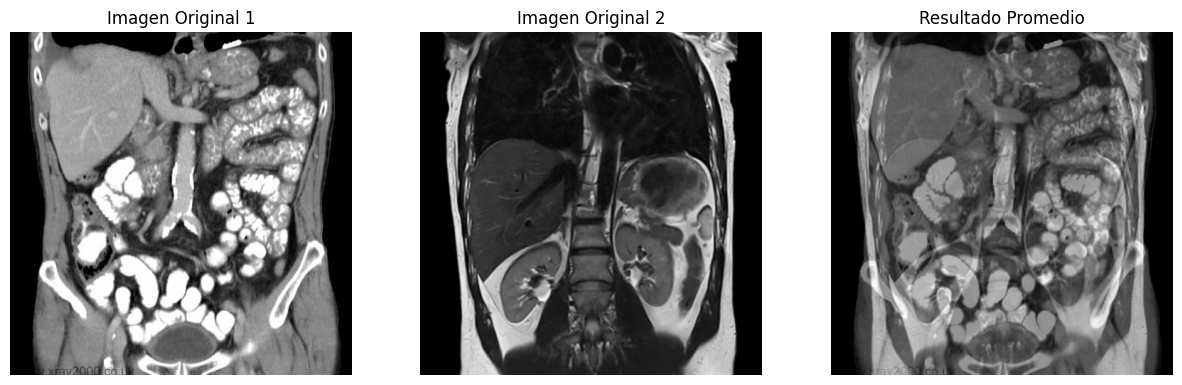

In [ ]:
# Cargar las dos imágenes
imagen1 = cv2.imread("MRI_ABDOMEN.jpg", cv2.IMREAD_GRAYSCALE)
imagen2 = cv2.imread("MRI_ABDOMEN2.jpg", cv2.IMREAD_GRAYSCALE)

# Redimensionar ambas imágenes al mismo tamaño si es necesario
imagen2_res = cv2.resize(imagen2, (imagen1.shape[1], imagen1.shape[0]))

# Convertir a float para evitar pérdida de información
img1_float = imagen1.astype(np.float32)
img2_float = imagen2_res.astype(np.float32)

# Calcular promedio
imagen_promedio = (img1_float + img2_float) / 2

# Convertir a uint8 para visualización
imagen_promedio = cv2.convertScaleAbs(imagen_promedio)

# Mostrar imágenes
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(imagen1, cmap="gray")
plt.title("Imagen Original 1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(imagen2_res, cmap="gray")
plt.title("Imagen Original 2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(imagen_promedio, cmap="gray")
plt.title("Resultado Promedio")
plt.axis("off")

plt.show()

### **Ejercicio 2**

Ahora se realiza una operación de resta entre dos imágenes utilizando la diferencia absoluta, lo que permite resaltar las diferencias de intensidad entre ambas sin generar valores negativos. En lugar de una resta directa, se emplea la función *cv2.absdiff*, la cual calcula la diferencia absoluta píxel a píxel.

El resultado es una nueva imagen en la que las zonas con mayor diferencia entre las imágenes originales aparecen más brillantes, mientras que las regiones similares tienden a verse más oscuras.

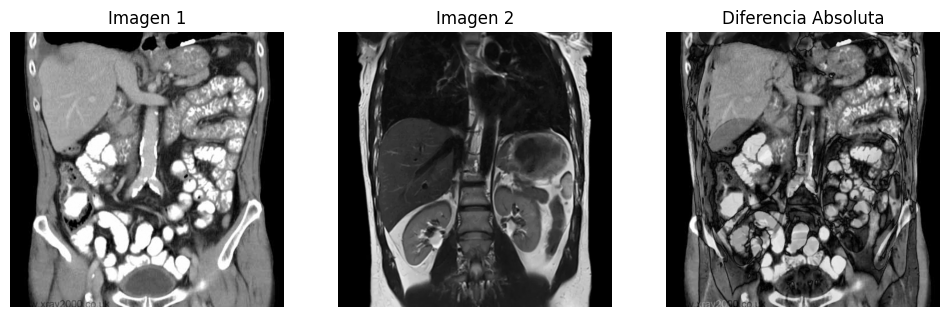

In [ ]:
# Cargar las dos imágenes
img1 = cv2.imread("MRI_ABDOMEN.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("MRI_ABDOMEN2.jpg", cv2.IMREAD_GRAYSCALE)

# Asegurar que tengan el mismo tamaño
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# Realizar la resta de imágenes (diferencia absoluta)
resta = cv2.absdiff(img2, img1)

# Mostrar imágenes originales y resultado
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img1, cmap='gray')
plt.title("Imagen 1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img2, cmap='gray')
plt.title("Imagen 2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resta, cmap='gray')
plt.title("Diferencia Absoluta")
plt.axis("off")

plt.show()

### **Ejercicio 3**

En este ejercicio se realiza una modificación del brillo de una imagen en escala de grises mediante multiplicación por diferentes factores. Para ello, se definen tres factores de escala (0.5, 1.0 y 1.5), que representan una disminución, mantenimiento y aumento del brillo, respectivamente.

Se utiliza un ciclo para aplicar cada uno de estos factores a la imagen original mediante la función *cv2.multiply*, la cual realiza una multiplicación píxel a píxel entre la imagen y el valor escalar correspondiente.


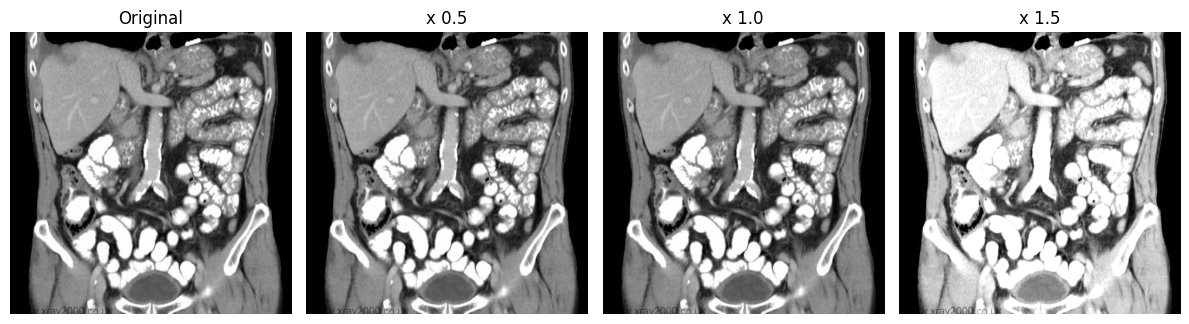

In [ ]:
# Cargar imagen en escala de grises
img = cv2.imread("MRI_ABDOMEN.jpg", cv2.IMREAD_GRAYSCALE)

# Factores de brillo
factores = [0.5, 1.0, 1.5]

# Crear figura
plt.figure(figsize=(12, 4))

# Mostrar imagen original
plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

# Aplicar factores
for i, f in enumerate(factores):
    img_mod = cv2.multiply(img, np.array([f], dtype=np.float32))
    img_mod = cv2.convertScaleAbs(img_mod)

    plt.subplot(1, 4, i+2)
    plt.imshow(img_mod, cmap='gray')
    plt.title(f"x {f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Se realiza el mismo procedimiento explicado anteriormente pero ahora para la segunda imagen, esto con el fin de comparar aún más resultados de la multiplicación por factor.

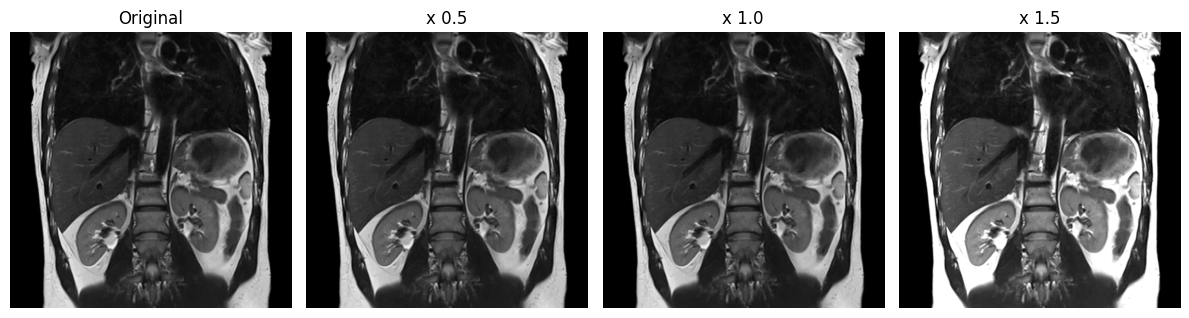

In [ ]:
# Cargar imagen en escala de grises
img = cv2.imread("MRI_ABDOMEN2.jpg", cv2.IMREAD_GRAYSCALE)

# Factores de brillo
factores = [0.5, 1.0, 1.5]

# Crear figura
plt.figure(figsize=(12, 4))

# Mostrar imagen original
plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

# Aplicar factores
for i, f in enumerate(factores):
    img_mod = cv2.multiply(img, np.array([f], dtype=np.float32))
    img_mod = cv2.convertScaleAbs(img_mod)

    plt.subplot(1, 4, i+2)
    plt.imshow(img_mod, cmap='gray')
    plt.title(f"x {f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### **Ejercicio 4**

A continuación, se realiza una multiplicación elemento a elemento entre dos imágenes en escala de grises, generando una nueva imagen en la que cada píxel es el resultado del producto de las intensidades correspondientes en ambas imágenes. Esta operación se lleva a cabo utilizando la función *cv2.multiply*, la cual aplica la multiplicación directamente sobre cada par de píxeles, permitiendo combinar la información de ambas imágenes de manera no lineal.

Las regiones donde ambas imágenes presentan valores altos tienden a intensificarse, mientras que aquellas donde al menos una de las imágenes tiene valores bajos se atenúan significativamente. Posteriormente, el resultado se convierte al formato *uint8* mediante *cv2.convertScaleAbs*, asegurando que los valores de intensidad se mantengan dentro del rango válido para su correcta visualización.


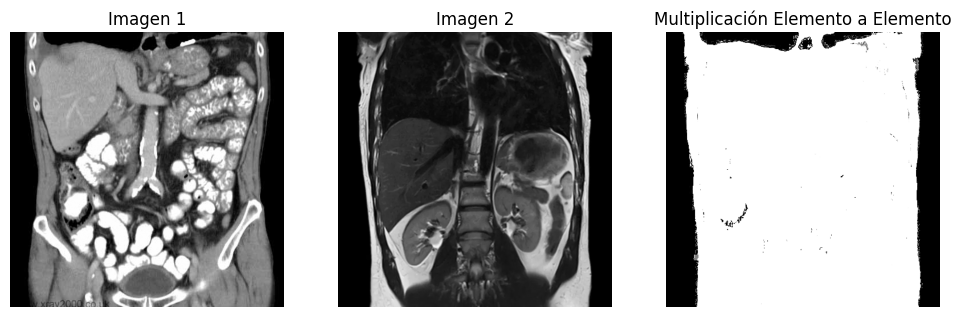

In [ ]:
# Cargar las dos imágenes en escala de grises
img1 = cv2.imread("MRI_ABDOMEN.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("MRI_ABDOMEN2.jpg", cv2.IMREAD_GRAYSCALE)

# Redimensionar para que tengan el mismo tamaño
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# Multiplicación elemento a elemento
img_multiplicada = cv2.multiply(img2, img1)  # OpenCV maneja el rango automáticamente

# Convertir la imagen resultante a uint8
img_multiplicada = cv2.convertScaleAbs(img_multiplicada)

# Mostrar imágenes originales y resultado
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img1, cmap='gray')
plt.title("Imagen 1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img2, cmap='gray')
plt.title("Imagen 2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_multiplicada, cmap='gray')
plt.title("Multiplicación Elemento a Elemento")
plt.axis("off")

plt.show()

# **Parte II**

### **Ejercicio 1**

Para la segunda parte de la actividad se aplica una ecualización de histograma a una imagen en escala de grises. La operación principal se realiza mediante la función *cv2.equalizeHist*, la cual redistribuye las intensidades de los píxeles para aprovechar de manera más uniforme todo el rango disponible.

Posteriormente, se calculan los histogramas de la imagen original y de la imagen ecualizada utilizando *cv2.calcHist*. Estos histogramas representan la distribución de frecuencias de los niveles de intensidad, permitiendo analizar cómo se encuentran distribuidos los píxeles antes y después del procesamiento. En la imagen original, es común observar concentraciones en ciertas zonas, mientras que en la imagen ecualizada la distribución tiende a ser más uniforme.


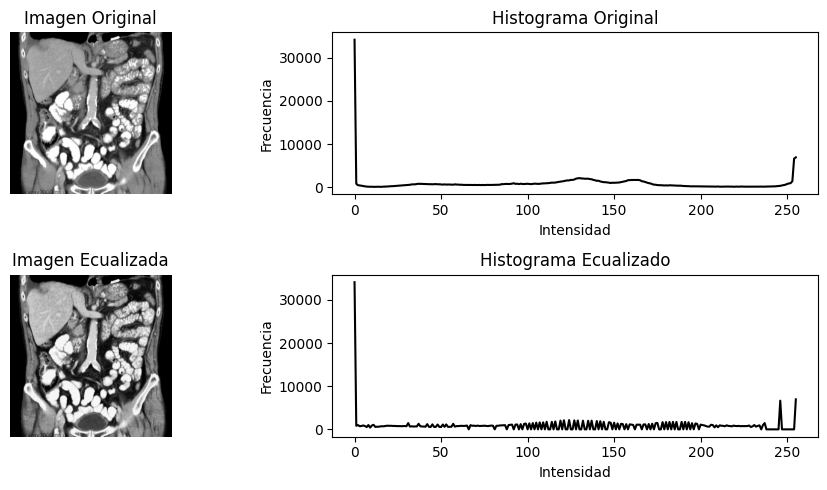

In [ ]:
# Cargar la imagen en escala de grises
imagen = cv2.imread("MRI_ABDOMEN.jpg", cv2.IMREAD_GRAYSCALE)

# Aplicar ecualización de histograma
imagen_ecualizada = cv2.equalizeHist(imagen)

# Calcular histogramas antes y después
hist_original = cv2.calcHist([imagen], [0], None, [256], [0,256])
hist_ecualizada = cv2.calcHist([imagen_ecualizada], [0], None, [256], [0,256])

# Mostrar imágenes y histogramas
plt.figure(figsize=(10,5))

# Imagen Original
plt.subplot(2,2,1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

# Histograma Original
plt.subplot(2,2,2)
plt.plot(hist_original, color="black")
plt.title("Histograma Original")
plt.xlabel("Intensidad")
plt.ylabel("Frecuencia")

# Imagen Ecualizada
plt.subplot(2,2,3)
plt.imshow(imagen_ecualizada, cmap="gray")
plt.title("Imagen Ecualizada")
plt.axis("off")

# Histograma Ecualizado
plt.subplot(2,2,4)
plt.plot(hist_ecualizada, color="black")
plt.title("Histograma Ecualizado")
plt.xlabel("Intensidad")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()